# CROCUS AQT archive — quick look

Loads the resampled AQT archive for one site and makes sanity-check plots.
Plots use the `mean` statistic. Trace-gas and particulate plots show the raw
series with **hard-fault** bins (from `qaqc_inventory`) masked out, so genuine
instrument errors (e.g. negative CO) don't dominate the axes. The raw values
remain in the archive untouched — masking is applied only for display.

The last cells show data availability (`count`) and a QA/QC flag summary.

In [27]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import crocus_store as cs
from crocus_sites import NEIU
import qaqc_inventory as q

importlib.reload(cs)
importlib.reload(q)

<module 'qaqc_inventory' from '/home/anderson/py/crocus/qaqc_inventory.py'>

In [ ]:
SITE = NEIU          # change to plot a different site
ds = cs.load(SITE, 'aqt', outdir='data/sage')

print('vars:', list(ds.data_vars))
print('span:', str(ds.time.values[0])[:10], '->', str(ds.time.values[-1])[:10])
print('bins:', ds.sizes['time'])

vars: ['humidity', 'pressure', 'temp', 'co', 'no', 'no2', 'o3', 'pm1', 'pm10', 'pm25']
span: 2023-05-05 -> 2025-12-15
bins: 261178


## QA/QC inventory

Dated, classified catalog of anomalies. Prints hard-faults, baseline-suspect stretches, and extreme-but-physical candidate events (annotated against known dates).

In [29]:
summary = q.inventory(ds)

# Compact per-channel tally for quick reference
print('\n--- summary ---')
for ch, s in summary.items():
    print(f"{ch:5s}  hard-fault={s['n_impossible_hard']:5d}  "
          f"baseline-suspect={s['n_baseline_suspect']:5d}  "
          f"extreme={s['n_extreme']:5d}")


=== co  [ppm] (typ<= 10.0, hard 0.0..50.0) ===
  bins: 261178  hard-fault: 12  baseline-suspect (sub-zero, needs calibration context): 8268  extreme-but-physical: 0
  HARD-FAULT episodes (likely instrument error):
    2024-01-25 21:10 .. 2024-01-25 21:15  (2 bins, range -9.45..-4.40, noisy)
    2024-10-08 21:15 .. 2024-10-08 21:35  (5 bins, range -6.20..-0.60, mixed)
    2025-06-03 18:30 .. 2025-06-03 18:50  (5 bins, range -6.56..-2.46, mixed)
  BASELINE-SUSPECT episodes (sub-zero; adjudicate w/ calibration data):
    2023-05-05 15:40 .. 2023-05-05 15:45  (2 bins, range -0.24..-0.04)
    2023-05-16 21:10 .. 2023-05-16 23:05  (22 bins, range -0.09..-0.01)
    2023-05-21 15:10 .. 2023-05-21 21:00  (63 bins, range -0.09..0.01)
    2023-05-22 22:10 .. 2023-05-22 22:35  (6 bins, range -0.01..-0.00)
    2023-05-25 06:10 .. 2023-05-25 08:35  (30 bins, range -0.04..-0.00)
    2023-06-01 17:45 .. 2023-06-01 17:45  (1 bins, range -0.00..-0.00)
    2023-06-03 18:35 .. 2023-06-03 19:00  (5 bins, 

## Build the hard-fault masks

Boolean masks marking only hard-fault bins, per channel. Used below to hide those bins from the plots. Baseline-suspect and extreme-but-physical are **not** masked — only genuine instrument errors are removed from view.

In [30]:
mask = q.build_flag_mask(ds)

def clean_series(var):
    """mean series with hard-fault bins masked to NaN (for display only),
    plus the raw series and stored units. Returns (raw, cleaned, units)."""
    da = ds[var].sel(statistic='mean')
    raw = da.to_series()
    flag_name = var + '_badflag'
    if flag_name in mask:
        cleaned = da.where(~mask[flag_name]).to_series()
    else:
        cleaned = raw
    return raw, cleaned, da.attrs.get('units', '')

## Meteorology

Temp / humidity / pressure are not in the gas/PM flag set, so these show raw (no QA/QC bounds defined for them here).

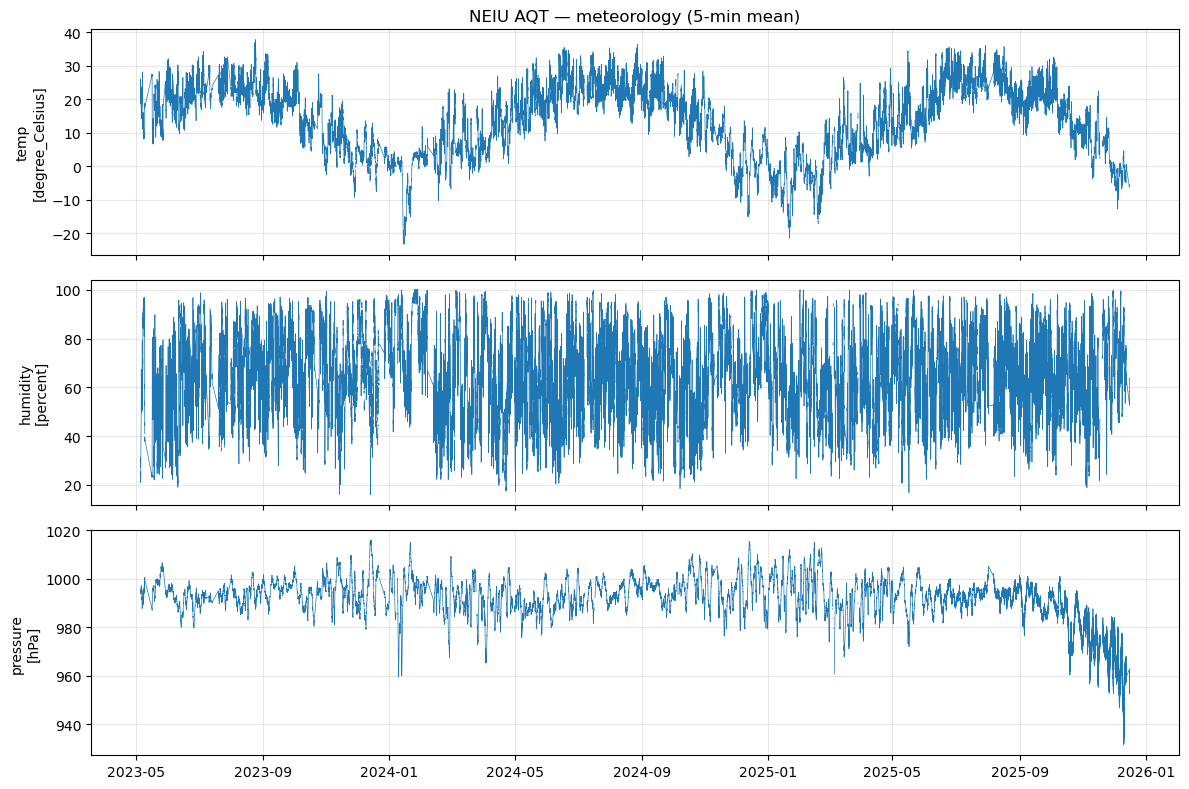

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, var in zip(axes, ['temp', 'humidity', 'pressure']):
    raw, cleaned, u = clean_series(var)
    ax.plot(raw.index, raw.values, lw=0.5)
    ax.set_ylabel(f'{var}\n[{u}]')
    ax.grid(alpha=0.3)
axes[0].set_title(f'{SITE.abbr} AQT — meteorology (5-min mean)')
fig.tight_layout()
plt.show()

## Trace gases (hard-faults masked)

Each panel shows the cleaned series (hard-fault bins removed). Faulted bins are marked with light red spans along the bottom so you can see *where* data was dropped, not just that it's gone.

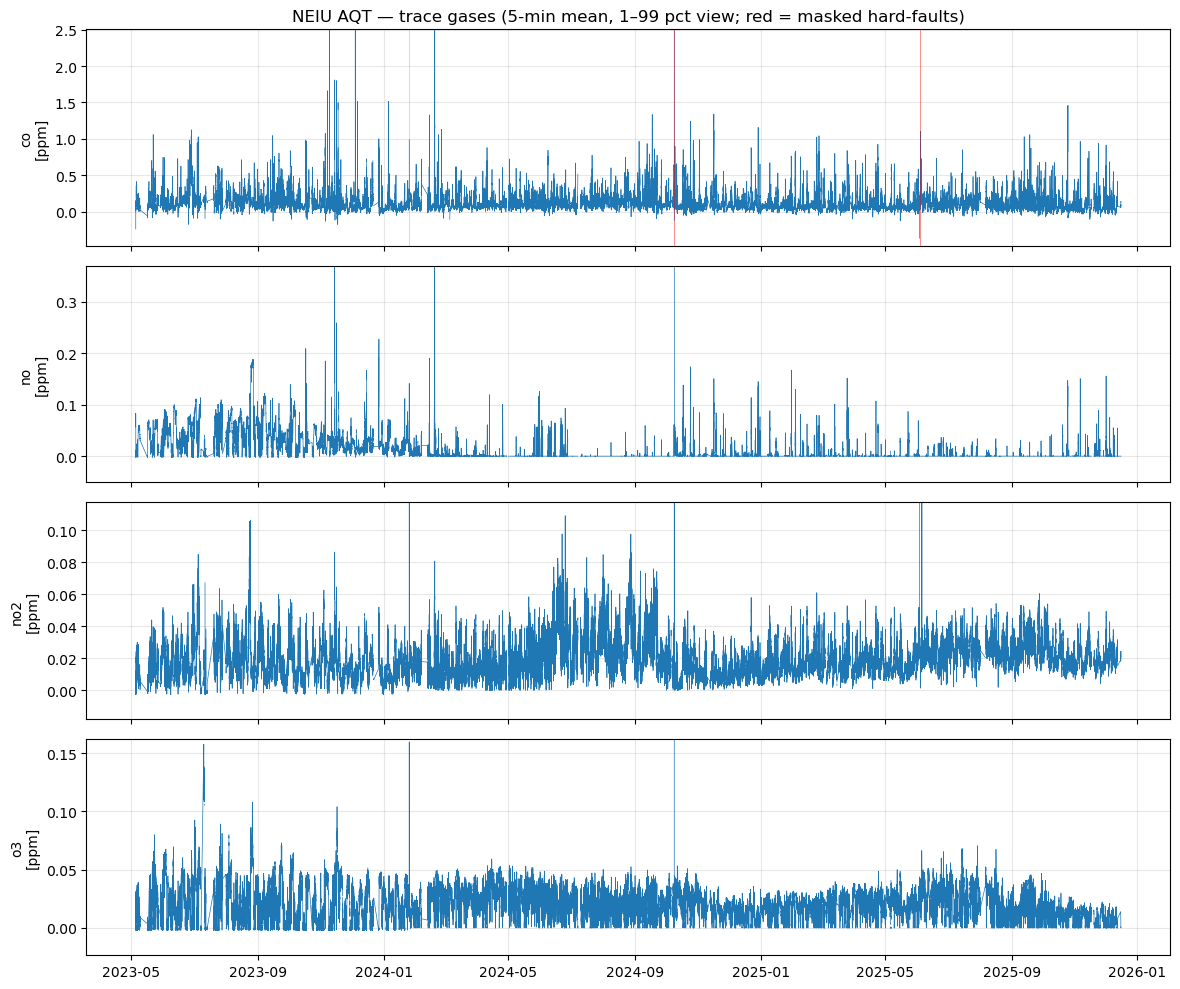

In [39]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, var in zip(axes, ['co', 'no', 'no2', 'o3']):
    raw, cleaned, u = clean_series(var)
    ax.plot(cleaned.index, cleaned.values, lw=0.5)
    # Robust y-limits: scale the view to the bulk of the data (1st-99th pct)
    # so large transient spikes don't flatten the diurnal variation. The
    # spikes are still plotted, just off the top of the view; nothing is
    # removed from the data.
    lo = cleaned.quantile(0.0001)
    hi = cleaned.quantile(0.9999)
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        pad = (hi - lo) * 0.15
        ax.set_ylim(lo - pad, hi + pad)
    # mark masked (hard-fault) bins as light spans at the axis bottom
    flag_name = var + '_badflag'
    if flag_name in mask:
        bad = mask[flag_name].to_series()
        bad_times = bad.index[bad.values]
        if 0 < len(bad_times) <= 500:
            for bt in bad_times:
                ax.axvline(bt, color='red', alpha=0.15, lw=0.5)
        elif len(bad_times) > 500:
            ax.text(0.01, 0.95, f'{len(bad_times)} masked bins',
                    transform=ax.transAxes, color='red', fontsize=8, va='top')
    ax.set_ylabel(f'{var}\n[{u}]')
    ax.grid(alpha=0.3)
axes[0].set_title(f'{SITE.abbr} AQT \u2014 trace gases (5-min mean, 1\u201399 pct view; red = masked hard-faults)')
fig.tight_layout()
plt.show()

## Particulates (hard-faults masked)

PM1 / PM2.5 / PM10 overlaid. Extreme-but-physical spikes (smoke, dust, fireworks) are *kept* — they're candidate real events, not faults — so big peaks here are expected and worth cross-referencing with the inventory's annotated episodes.

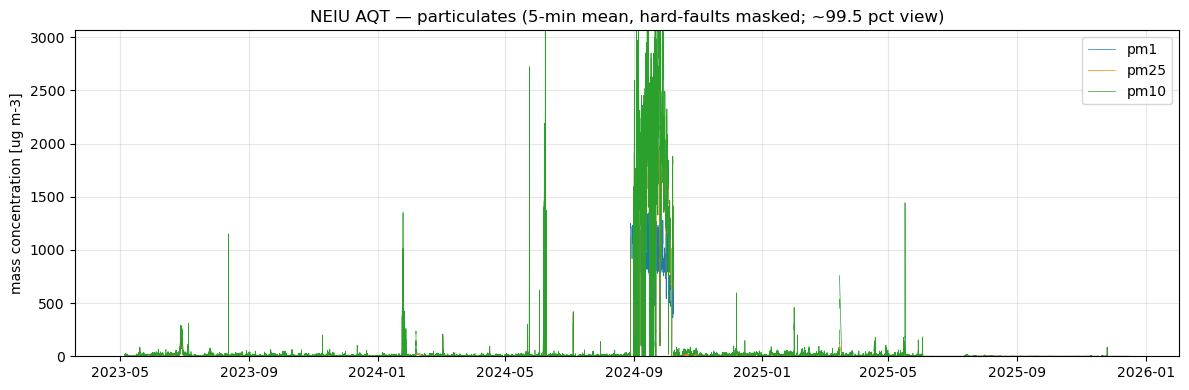

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))
hi_all = []
for var in ['pm1', 'pm25', 'pm10']:
    raw, cleaned, u = clean_series(var)
    ax.plot(cleaned.index, cleaned.values, lw=0.5, label=var)
    hi_all.append(cleaned.quantile(0.995))
_, _, u = clean_series('pm25')
# robust upper limit across the three series; real spikes still extend above
hi = np.nanmax(hi_all)
if np.isfinite(hi) and hi > 0:
    ax.set_ylim(0, hi * 1.2)
ax.set_ylabel(f'mass concentration [{u}]')
ax.set_title(f'{SITE.abbr} AQT \u2014 particulates (5-min mean, hard-faults masked; ~99.5 pct view)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Raw vs cleaned (CO)

Direct before/after for CO, the channel with the clearest faults (negative values). Shows what masking removes and what survives.

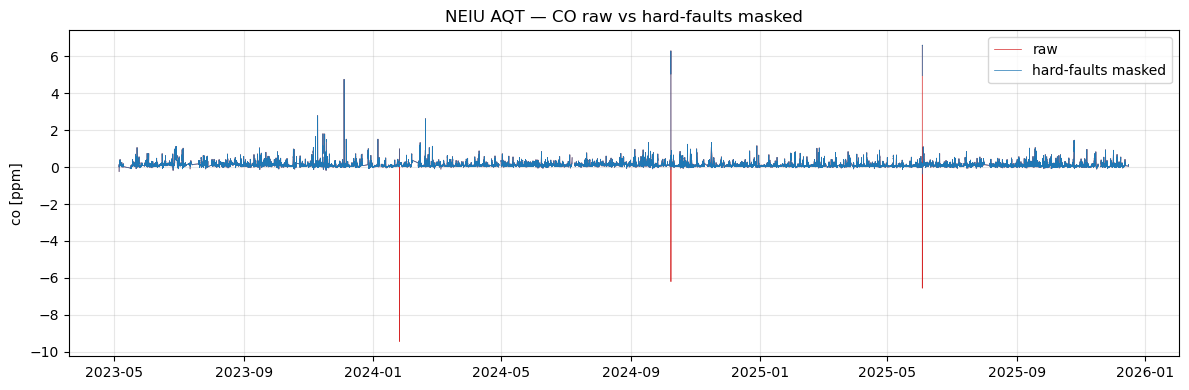

In [38]:
raw, cleaned, u = clean_series('co')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw.index, raw.values, lw=0.5, color='tab:red', label='raw')
ax.plot(cleaned.index, cleaned.values, lw=0.5, color='C0', label='hard-faults masked')
ax.set_ylabel(f'co [{u}]')
ax.set_title(f'{SITE.abbr} AQT — CO raw vs hard-faults masked')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Data availability

`count` is the number of raw samples behind each 5-min bin. Flat high values mean steady reporting; drops toward zero flag gaps or outages.

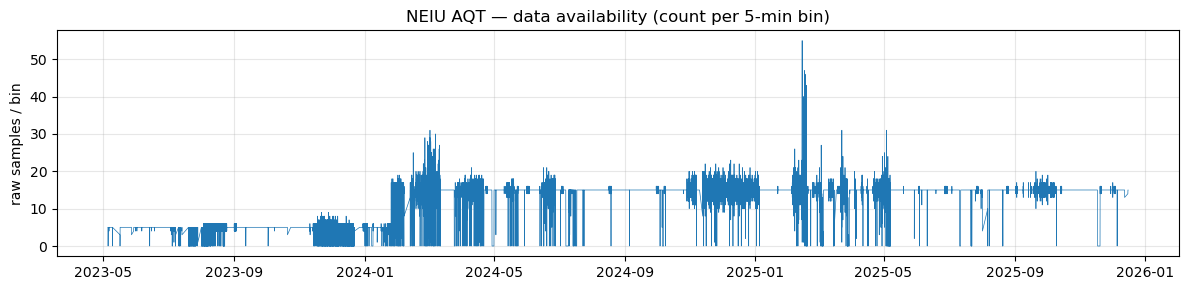

median samples/bin: 15
empty bins (count==0): 7261


In [35]:
count = ds['temp'].sel(statistic='count').to_series()
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(count.index, count.values, lw=0.5)
ax.set_ylabel('raw samples / bin')
ax.set_title(f'{SITE.abbr} AQT — data availability (count per 5-min bin)')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print('median samples/bin:', int(count.median()))
print('empty bins (count==0):', int((count == 0).sum()))

In [36]:
ds.close()